In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [6]:
adata.obs.timepoint_tx_days = adata.obs.timepoint_tx_days.astype(int)

In [7]:
celltype_pallete = {"HSC":"#E278C6","Meg":"#AFC7E5","Mono/DC prog":"#FFC58B",
 "Int prog":"#C8C8C8","Ery":"#8C554A","Eos":"#AD40FC",
 "Neu":"#9BDD91","Bas/MC prog":"#279F6A","Ly":"#31C6D3"}

In [8]:
adata.uns['anno_man_colors'] = [celltype_pallete[ct] for ct in adata.obs.anno_man.cat.categories]

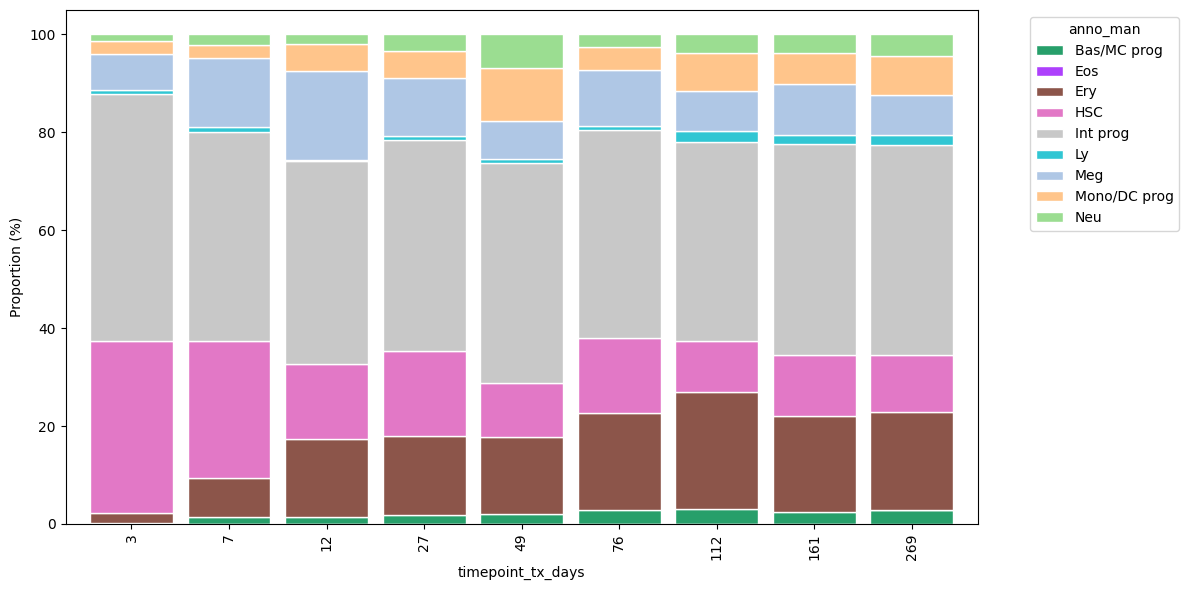

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='timepoint_tx_days', ylabel='Proportion (%)'>)

In [9]:
PINN.pl.obs_composition(adata, x_var='timepoint_tx_days', y_var='anno_man',kind='bar')

# density estimate

In [10]:
cellstate_key = "DM_scaled"
n_dimension = 10

Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key='Delta_DM',
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


In [11]:
Dataset.u_b.shape

torch.Size([9, 49390])

In [12]:
def sum_density_by_label(adata, obs_key, density, timepoint_key='timepoint_tx_days', timepoints=None, agg_fn='sum'):

    df = adata.obs.copy()

    if timepoints is None:
        timepoints = df[timepoint_key].unique()

    sum_u_t = []

    for i, t in enumerate(sorted(timepoints)):
        
        df[f"u"] = density[i]
        agg_u = df[['u', obs_key]].groupby(obs_key).agg(agg_fn)
        agg_u = agg_u.rename({"u":t}, axis=1)
        agg_u = agg_u / agg_u.sum()
        sum_u_t.append(agg_u)

    return pd.concat(sum_u_t, axis=1)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

data = Dataset.cellstate
k = 10  # 根据数据调整
nbrs = NearestNeighbors(n_neighbors=k).fit(data)
distances, _ = nbrs.kneighbors(data)
adaptive_h = distances[:,:].mean()  # 取第k近邻的距离作为h_i

In [20]:
distances.shape

(49390, 10)

In [ ]:
def agg_plot(power, agg_fn, k=10):
    # cell_volumn = np.abs(Dataset.deltax.prod(axis=1, keepdims=True)
    #                 )**power

    # cell_volumn = np.abs(Dataset.deltax).max(axis=1,keepdims=True)**power
    cell_volumn = np.power(Dataset.deltax,2).sum(axis=1,keepdims=True)**power

    
    nbrs = NearestNeighbors(n_neighbors=k).fit(data)
    distances, _ = nbrs.kneighbors(data)
    adaptive_h = distances[:,-2:].mean(axis=1)  # get the kth nearest distance
    cell_volumn = adaptive_h**power

    area_u = Dataset.u_b.numpy() * np.abs(cell_volumn.T)

    print(area_u.sum(axis=1))
    agg_u = sum_density_by_label(adata, 'anno_man', area_u, 
                            timepoint_key='timepoint_tx_days', agg_fn=agg_fn)
    color = adata.uns['anno_man_colors']
    agg_u.T.plot.bar(
            stacked=True,
            width=0.85,       # Bar width
            edgecolor='white', # Optional: adds separation between bars
            color=adata.uns['anno_man_colors']
            )

    plt.legend(
            title='annotation',
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
    )   
    plt.title(f"power = {power}")

[  1.           2.64384835   3.92308095  12.56231284  21.24678711
  56.01314719  94.89488451 133.58129483 283.82983651]
[ 0.06666488  0.18636181  0.28515701  0.90434833  1.51628574  4.0534353
  6.99433592  9.58173467 20.6125057 ]
[0.00473091 0.0142767  0.02255478 0.07054768 0.11643813 0.31912236
 0.55599714 0.74368934 1.6141663 ]
[3.10590999e-05 1.15520851e-04 1.95125041e-04 5.80455006e-04
 9.22338163e-04 2.69124294e-03 4.71715309e-03 6.13762596e-03
 1.33420819e-02]
[3.59814007e-07 1.69441462e-06 3.30123542e-06 8.36978215e-06
 1.38196461e-05 3.84515990e-05 6.99387487e-05 1.03050790e-04
 2.02739269e-04]
[9.34013303e-09 5.11225878e-08 2.02661849e-07 2.59922309e-07
 6.41192436e-07 1.05215843e-06 2.22448850e-06 1.01188653e-05
 1.03281165e-05]


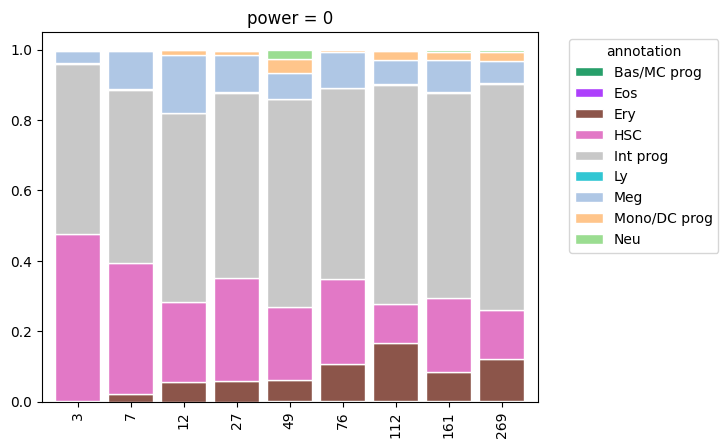

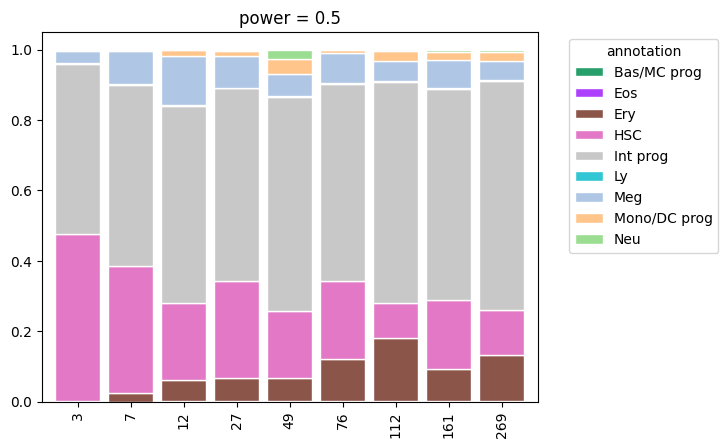

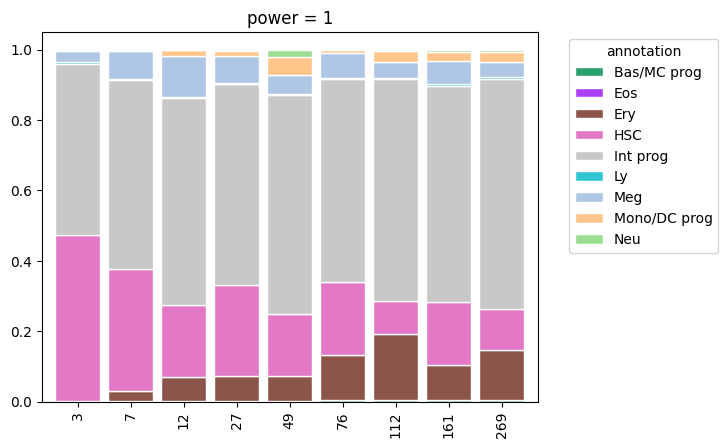

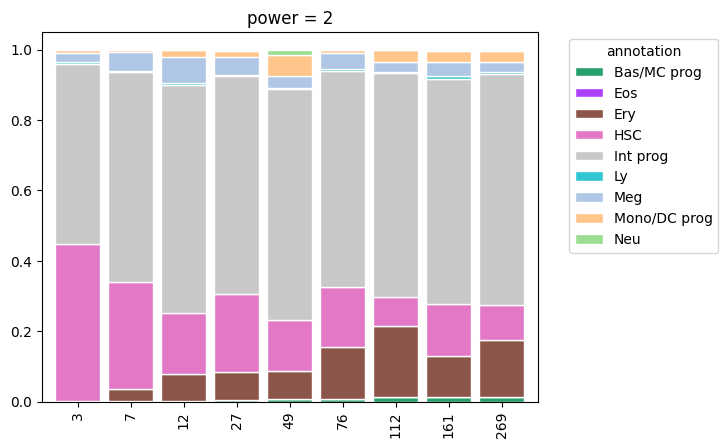

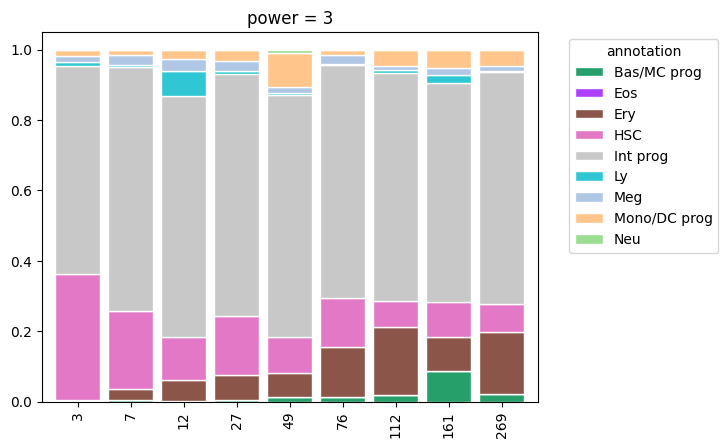

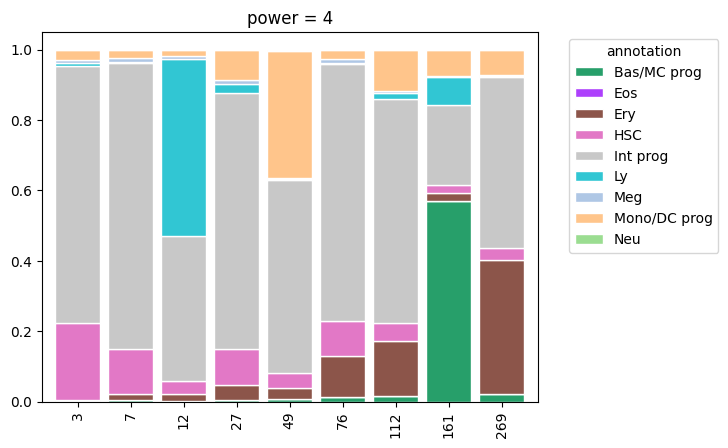

In [37]:
agg_fn = 'sum'

for p in [0, 0.5, 1, 2, 3,4]:
    
    agg_plot(p, agg_fn, k=20)